In [1]:
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

In [8]:
from imblearn.datasets import fetch_datasets

from imblearn.pipeline import make_pipeline

from imblearn.over_sampling import(
    RandomOverSampler,
    SMOTE,
    ADASYN,
    BorderlineSMOTE,
    SVMSMOTE,
)

In [2]:
import imblearn.over_sampling

In [7]:
for item in dir(imblearn.over_sampling):
    if 'random' in item.lower() or 'smote' in item.lower() or 'adasyn' in item.lower():
        print(item + ',')

ADASYN,
BorderlineSMOTE,
KMeansSMOTE,
RandomOverSampler,
SMOTE,
SMOTEN,
SMOTENC,
SVMSMOTE,
_adasyn,
_random_over_sampler,
_smote,


In [9]:
oversampler_dict = {
    'random': RandomOverSampler(
    sampling_strategy='auto',
    random_state=0,
),
    'smote': SMOTE(sampling_strategy='auto', random_state=0, k_neighbors=5),
    'adasyn': ADASYN(sampling_strategy='auto', random_state=0, n_neighbors=5),
    'border1': BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-1',
),
    'border2': BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-2',
),
    'svm': SVMSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    svm_estimator=SVC(kernel='linear'),
    out_step=0.5,
)}

In [10]:
datasets_ls = [
    'car_eval_34',
    'ecoli',
    'thyroid_sick',
    'arrhythmia',
    'ozone_level']


In [11]:
#print class imbalance

for dataset in datasets_ls:
    data = fetch_datasets()[dataset]
    print(dataset)
    print(Counter(data.target))
    print()

car_eval_34
Counter({np.int64(-1): 1594, np.int64(1): 134})

ecoli
Counter({np.int64(-1): 301, np.int64(1): 35})

thyroid_sick
Counter({np.int64(-1): 3541, np.int64(1): 231})

arrhythmia
Counter({np.int64(-1): 427, np.int64(1): 25})

ozone_level
Counter({np.int64(-1): 2463, np.int64(1): 73})



In [13]:
def run_model(X_train, y_train, oversampler=None):

    #setting up the classifier
    rf = RandomForestClassifier(
        n_estimators=100, random_state=0, max_depth=3, n_jobs=-1
    )

    #set up a scaler
    #as KNN a distance-based techniques, we need to have the variables in the same scale

    scaler = MinMaxScaler()

    #case without oversampling
    if not oversampler:
        model = rf

    #setting up a pipeline for sampling
    else:

        #important to scale before the resampler
        model = make_pipeline(
            scaler,
            oversampler,
            rf
        )

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        scoring='average_precision',
        cv=3
    )

    print(
        'Random Forests average precision: {0} +/- {1}'.format(cv_results['test_score'].mean(), cv_results['test_score'].std())
    )

    return cv_results['test_score'].mean(), cv_results['test_score'].std()

In [16]:
pr_mean_dict = {}
pr_std_dict = {}

for dataset in datasets_ls:

    #initiate a dictionary per dataset
    pr_mean_dict[dataset] = {}
    pr_std_dict[dataset] = {}

    print(dataset)

    #Loading the dataset
    data = fetch_datasets()[dataset]

    #Separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(
        data.data,
        data.target,
        test_size=0.3,
        random_state=0
    )

    #train model on data without resampling with cross-validation
    aps_mean, aps_std = run_model(X_train, y_train)

    #store results
    pr_mean_dict[dataset]['full_data'] = aps_mean
    pr_std_dict[dataset]['full_data'] = aps_std

    print()

    for oversampler in oversampler_dict.keys():

        print(oversampler)

        #resample, train and evaluate performance with cross-validation
        aps_mean, aps_std = run_model(X_train, y_train, oversampler_dict[oversampler])

        #store results
        pr_mean_dict[dataset][oversampler] = aps_mean
        pr_std_dict[dataset][oversampler] = aps_std
        print()
    print()

car_eval_34
Random Forests average precision: 0.726499046279681 +/- 0.0948292750824211

random
Random Forests average precision: 0.8579923976199165 +/- 0.08778206502244199

smote
Random Forests average precision: 0.8018720707917592 +/- 0.06721604927994458

adasyn
Random Forests average precision: 0.8575699160000761 +/- 0.07294494634996761

border1
Random Forests average precision: 0.8469352019805627 +/- 0.0614894271723966

border2
Random Forests average precision: 0.87408105700871 +/- 0.05664696931142181

svm
Random Forests average precision: 0.6430552105502461 +/- 0.06147508842601533


ecoli
Random Forests average precision: 0.6691869350249872 +/- 0.11345338962267322

random
Random Forests average precision: 0.5558739833607499 +/- 0.0029130648009329276

smote
Random Forests average precision: 0.5663041819291819 +/- 0.03725017773481663

adasyn
Random Forests average precision: 0.5956313278777047 +/- 0.04557792838581666

border1
Random Forests average precision: 0.5439706323460424 +/- 0

In [14]:
?make_pipeline

Signature: make_pipeline(*steps, memory=None, transform_input=None, verbose=False)
Docstring:
Construct a Pipeline from the given estimators.

This is a shorthand for the Pipeline constructor; it does not require, and
does not permit, naming the estimators. Instead, their names will be set
to the lowercase of their types automatically.

Parameters
----------
*steps : list of estimators
    A list of estimators.

memory : None, str or object with the joblib.Memory interface, default=None
    Used to cache the fitted transformers of the pipeline. By default,
    no caching is performed. If a string is given, it is the path to
    the caching directory. Enabling caching triggers a clone of
    the transformers before fitting. Therefore, the transformer
    instance given to the pipeline cannot be inspected
    directly. Use the attribute ``named_steps`` or ``steps`` to
    inspect estimators within the pipeline. Caching the
    transformers is advantageous when fitting is time consuming.


In [15]:
?imblearn.pipeline.Pipeline

Init signature:
imblearn.pipeline.Pipeline(
    steps,
    *,
    transform_input=None,
    memory=None,
    verbose=False,
)
Docstring:     
Pipeline of transforms and resamples with a final estimator.

Sequentially apply a list of transforms, sampling, and a final estimator.
Intermediate steps of the pipeline must be transformers or resamplers,
that is, they must implement fit, transform and sample methods.
The samplers are only applied during fit.
The final estimator only needs to implement fit.
The transformers and samplers in the pipeline can be cached using
``memory`` argument.

The purpose of the pipeline is to assemble several steps that can be
cross-validated together while setting different parameters.
For this, it enables setting parameters of the various steps using their
names and the parameter name separated by a '__', as in the example below.
A step's estimator may be replaced entirely by setting the parameter
with its name to another estimator, or a transformer removed 

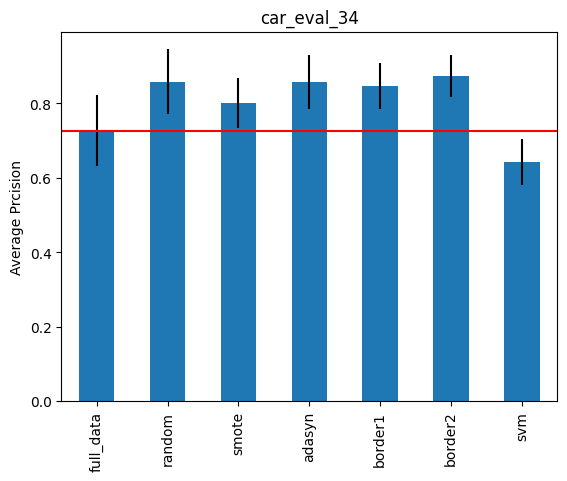

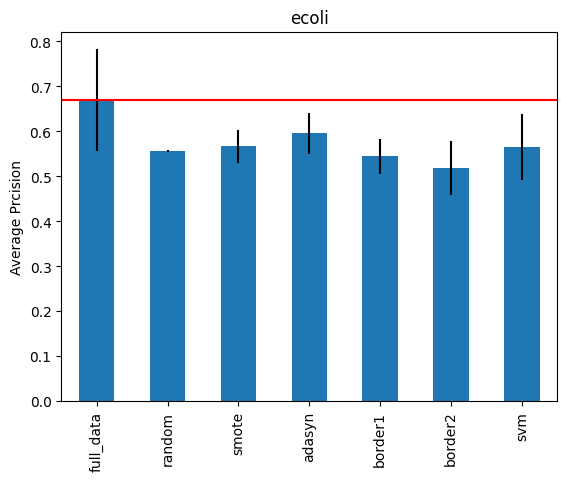

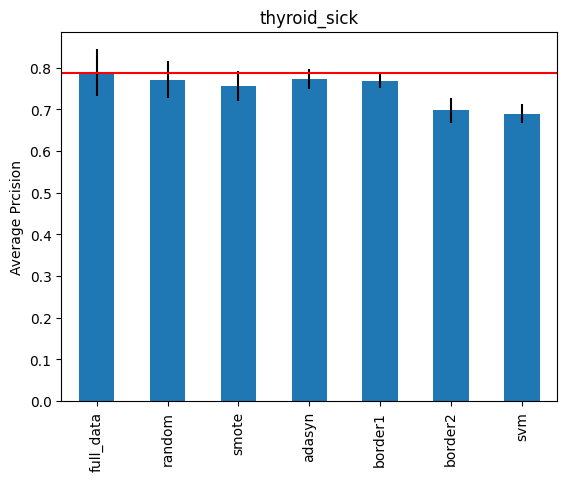

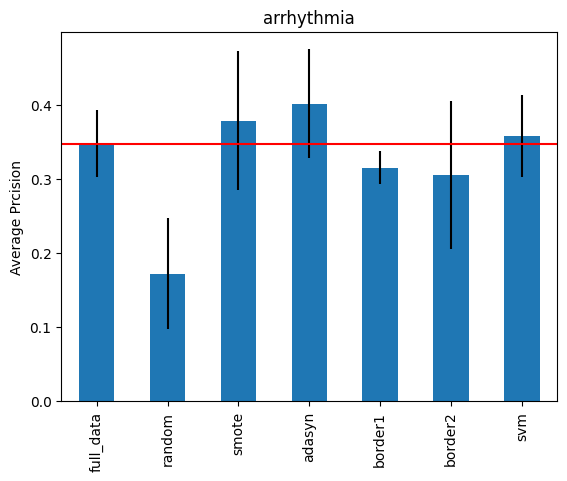

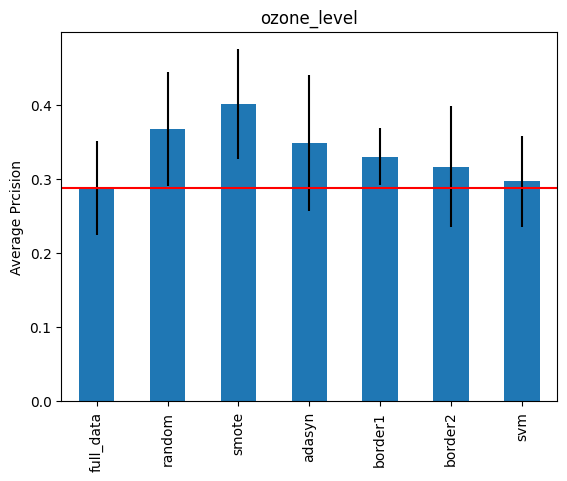

In [20]:
for dataset in datasets_ls:
    
    pr_mean_series = pd.Series(pr_mean_dict[dataset])
    pr_std_series = pd.Series(pr_std_dict[dataset])

    pr_mean_series.plot.bar(yerr=pr_std_series)
    plt.title(dataset)
    plt.ylabel('Average Prcision')
    plt.axhline(pr_mean_dict[dataset]['full_data'], c='red')
    plt.show()